In [1]:
!pip install -q -U torchao
!pip install -q pytrec_eval
!pip install -q rank-bm25

!pip install -q colpali-engine
!pip install -q open_clip_torch==2.23.0
!pip install -q git+https://github.com/Mahmoodlab/CONCH.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 52.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.3/112.3 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [1]:
import shutil
import os

def updated_repo():
    repo_path = "/content/retrieval-benchmark"

    if os.path.exists(repo_path):
        shutil.rmtree(repo_path)

    get_ipython().system(
        "git clone https://github.com/Archit381/retrieval-benchmark.git"
    )

In [2]:
import sys
import torch

updated_repo()

sys.path.append("/content/retrieval-benchmark")

DEVICE = "cuda:0" if torch.cuda.is_available() else "cpu"
print(DEVICE)

model_map = {
    "colsmol": "vidore/colSmol-500M",
    "biomedclip": "microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224",
    "conch": "MahmoodLab/conch",
    "pubmedclip": "flaviagiammarino/pubmed-clip-vit-base-patch32"
}

Cloning into 'retrieval-benchmark'...
remote: Enumerating objects: 170, done.
remote: Counting objects: 100% (170/170), done.
remote: Compressing objects: 100% (111/111), done.
remote: Total 170 (delta 98), reused 128 (delta 56), pack-reused 0 (from 0)
Receiving objects: 100% (170/170), 2.24 MiB | 6.88 MiB/s, done.
Resolving deltas: 100% (98/98), done.
cuda:0


## Simple evaluation

In [3]:
# from src.core import load_artifacts_hf, compare_ndcg
# from src.evaluation_factory import evaluate

# eval_results = {}

# for model_type in model_map.keys():
#   embds, manifest = load_artifacts_hf(
#       repo_id="architojha/m3-retrieve-eval",
#       subfolder=model_type,
#       device=DEVICE,
#       force_download=True,
#   )

#   result = evaluate(
#         model_type=model_type,
#         query_embs=embds.sets["query_image"],
#         doc_embs=embds.sets["doc"],
#         query_ids=manifest.query_ids,
#         doc_ids=manifest.doc_ids,
#         qrels=embds.qrels,
#         device=DEVICE,
#     )

#   eval_results[model_type] = result
# ndcg_df = compare_ndcg(eval_results)

## Using GQR

In [4]:
from src.core import load_artifacts_hf

REPO   = "architojha/m3-retrieve-eval"

col_ctx, col_manifest = load_artifacts_hf(
    repo_id=REPO, subfolder="colsmol", device=DEVICE, force_download=True
)

bio_ctx, bio_manifest = load_artifacts_hf(
    repo_id=REPO, subfolder="biomedclip", device=DEVICE, force_download=True
)

query_ids = col_manifest.query_ids
doc_ids   = col_manifest.doc_ids
qrels     = col_ctx.qrels

q_embs_col = col_ctx.sets["query_image"]   # list[Tensor] — ColSmol image queries
d_embs_col = col_ctx.sets["doc"]           # list[Tensor] — ColSmol docs

q_embs_bio = bio_ctx.sets["query_image"]   # Tensor [Nq, D] — BiomedCLIP image queries
d_embs_bio = bio_ctx.sets["doc"]           # Tensor [Nd, D] — BiomedCLIP docs

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 22 files:   0%|          | 0/22 [00:00<?, ?it/s]

Fetching 22 files:   0%|          | 0/22 [00:00<?, ?it/s]

In [5]:
from src.evaluation_factory import evaluate, apply_test_time_method
from src.evaluation.test_time import GQRMethod

primary  = evaluate("colsmol",    q_embs_col, d_embs_col, query_ids, doc_ids, qrels, device=DEVICE)
feedback = evaluate("biomedclip", q_embs_bio, d_embs_bio, query_ids, doc_ids, qrels, device=DEVICE)

print("sim_main device:    ", primary["similarity_matrix"].device)
print("sim_feedback device:", feedback["similarity_matrix"].device)

sim_main device:     cuda:0
sim_feedback device: cuda:0


[GQR] Query 1/58 | Step 1: 0.0002 → Step 30: 0.0000
[GQR] Query 2/58 | Step 1: 0.0002 → Step 30: 0.0000
[GQR] Query 3/58 | Step 1: 0.0001 → Step 30: 0.0000
[GQR] Query 4/58 | Step 1: 0.0000 → Step 30: 0.0000
[GQR] Query 5/58 | Step 1: 0.0001 → Step 30: 0.0000
[GQR] Query 6/58 | Step 1: 0.0001 → Step 30: 0.0000
[GQR] Query 7/58 | Step 1: 0.0002 → Step 30: 0.0000
[GQR] Query 8/58 | Step 1: 0.0001 → Step 30: 0.0000
[GQR] Query 9/58 | Step 1: 0.0002 → Step 30: 0.0000
[GQR] Query 10/58 | Step 1: 0.0003 → Step 30: 0.0000
[GQR] Query 11/58 | Step 1: 0.0001 → Step 30: 0.0000
[GQR] Query 12/58 | Step 1: 0.0002 → Step 30: 0.0000
[GQR] Query 13/58 | Step 1: 0.0001 → Step 30: 0.0000
[GQR] Query 14/58 | Step 1: 0.0001 → Step 30: 0.0000
[GQR] Query 15/58 | Step 1: 0.0002 → Step 30: 0.0000
[GQR] Query 16/58 | Step 1: 0.0002 → Step 30: 0.0000
[GQR] Query 17/58 | Step 1: 0.0001 → Step 30: 0.0000
[GQR] Query 18/58 | Step 1: 0.0002 → Step 30: 0.0000
[GQR] Query 19/58 | Step 1: 0.0002 → Step 30: 0.0000
[G

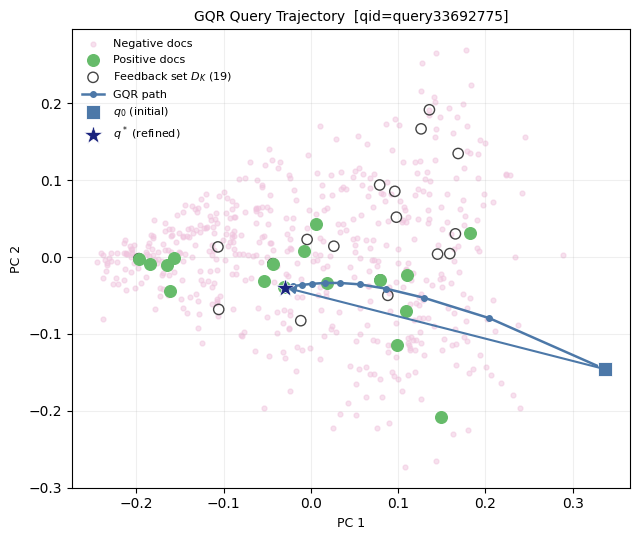

[GQR] loss curve plot saved → results/figures/gqr_losses.png


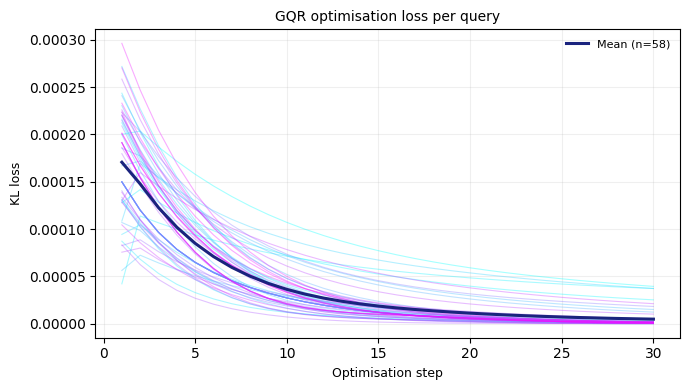

In [6]:
from src.evaluation import ColSmolEvaluator, DenseEvaluator
from src.evaluation.scoring import gqr_score_multi_vector

gqr = GQRMethod(
    primary_evaluator=ColSmolEvaluator(device=DEVICE),
    sim_func=gqr_score_multi_vector,
    lr=5e-3,
    n_steps=30,
)

gqr_result = apply_test_time_method(
    gqr,
    q_embs_col, d_embs_col,
    primary["similarity_matrix"],
    feedback["similarity_matrix"],
    query_ids, doc_ids, qrels,
    plot_trajectory=True,
    plot_losses=True,
    plots_save_path="results/figures",
    plot_query_idx=3,   # optional, defaults to 0
)


In [7]:
from src.evaluation.test_time import AverageRankFusion, AverageScoreFusion

rank_result = apply_test_time_method(
      AverageRankFusion(), None, None,
      primary["similarity_matrix"],
      feedback["similarity_matrix"],
      query_ids, doc_ids, qrels,
  )

score_result = apply_test_time_method(
    AverageScoreFusion(), None, None,
    primary["similarity_matrix"],
    feedback["similarity_matrix"],
    query_ids, doc_ids, qrels,
)

In [8]:
from src.core import  compare_ndcg

eval_results = {
    "colsmol": primary,
    "biomedclip": feedback,
    "avg_score_fusion": score_result,
    "avg_rank_fusion": rank_result,
    "gqr": gqr_result
}

ndcg_df = compare_ndcg(eval_results)


================ NDCG @ [1, 5, 10] ================


,nDCG@1,nDCG@5,nDCG@10
Model,,,
avg_score_fusion,0.397,0.329,0.301
gqr,0.379 (-4.3\%),0.307 (-6.6\%),0.292 (-2.8\%)
BiomedCLIP,0.336 (-15.2\%),0.272 (-17.3\%),0.265 (-12.0\%)
avg_rank_fusion,0.353 (-10.9\%),0.243 (-26.2\%),0.247 (-17.9\%)
ColSmol-500M,0.026 (-93.5\%),0.084 (-74.3\%),0.074 (-75.4\%)
